In [7]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'


In [8]:
 
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata.txt'
# Generate loop_info DataFrame

In [20]:
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]
dic_area_of_interest = {}
dic_area_of_interest['FilchnerRonne'] = ['_sector_5','_sector_11']
dic_area_of_interest['Ross'] = ['_sector_2','_sector_6']
dic_area_of_interest['Amundsen'] = ['_sector_4']

In [24]:
yearstrings=['2100','2200','2300']
for k,year in enumerate([2100,2200,2298]):
    yearstring= yearstrings[k]
    models=[]
    paths =[]
    exps =[]
    for exp in expnames:
        lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
        lst.sort()

        for name in lst:
            model = get_model(name,exp)
            if model in removeFileID:
                continue
            else:
                models.append(model)
                paths.append(name)
                exps.append(exp)
    df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
    for i in range(1,19):
        df['sector_'+str(i)]=0
    df['AIS']=0
    for i in range(1,4):
        df['region_'+str(i)]=0
    for key in dic_area_of_interest.keys():
        df[key]=0


    df2 = df.copy()
    df2['MAx']=0
    for i in range (df.shape[0]):
        pth_way = df.iloc[i].Path
        #get shelf area
        pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/iareafl/computed_iareafl_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
        pth_tf = f'{pth_imip6hack}/{df.iloc[i].Experiment}/thermalforcing/computed_thermalforcing_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'

        #
        # Area
        d2 = xr.open_dataset(pth_area,decode_times=False )
        #thermal foring 



        tmin = d2.time.size
        ind = np.where(d2.time.values <= year)[0][-1]


        #melting per area
        y =d2.iareafl.values#GT/m^3 yr
        y_100 = y[0]
        y_end = y[ind]
        rel = (y_end-y_100)/y_100 *100






        df['AIS'].iloc[i]= rel
    #     df2['AIS'].iloc[i]= x[:50].mean()

        for j in range(1,19):
            y =d2['iareafl_sector_'+str(j)].values[:tmin]  #GT/m^3 yr
            y_100 = y[0]
            y_end = y[ind]
            rel = (y_end-y_100)/y_100 *100




            df['sector_'+str(j)].iloc[i] = rel


        for j in range(1,4):
            y =d2['iareafl_region_'+str(j)].values[:tmin]  #GT/m^3 yr
            y_100 = y[0]
            y_end = y[ind]
            rel = (y_end-y_100)/y_100 *100






            df['region_'+str(j)].iloc[i] = rel
            
            
        for key in dic_area_of_interest.keys():
            sectors = dic_area_of_interest[key].copy()
            ys = np.zeros((len(sectors),tmin))
            y_100=0
            y_end =0
            for j,sector in enumerate(sectors):
                y =d2[f'iareafl{sector}'].values[:tmin] 
                y_100= y_100+y[0]
                y_end =y_end+ y[ind]
                
            rel = (y_end-y_100)/y_100 *100

            df[key].iloc[i]=rel
        
        
        df.to_csv(f'tables/precentage_change_ofIceShelf_{yearstring}.csv', index=False)
    #         df2['sector_'+str(j)].iloc[i] = x[:50].max()

    #         if (j==1 and i ==4):
    #             print(d2['iareafl_sector_'+str(j)].values[:tmin])
    #             break


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_30757/2983007647.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AIS'].iloc[i]= rel
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_30757/2983007647.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sector_'+str(j)].iloc[i] = rel
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_30757/2983007647.py:85: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

In [23]:
df

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,sector_16,sector_17,sector_18,AIS,region_1,region_2,region_3,FilchnerRonne,Ross,Amundsen
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,-63.039815,-58.673155,-25.739586,13.460813,-55.428302,-92.183667,67.803127,...,-72.619975,-92.202878,-72.072095,-63.874048,-53.889662,-69.970185,-78.987229,-58.397114,-74.040573,13.460813
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,-83.706391,-6.762636,-77.340060,-15.628329,-19.501901,-20.996265,74.066126,...,-93.614173,-96.965450,-83.937842,-41.711313,-20.102638,-52.600718,-91.207355,-26.208774,-13.250337,-15.628329
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,-92.000800,-42.046958,-96.253568,32.083455,-75.354671,-98.519498,-30.013332,...,-93.141699,-99.669135,-92.517322,-74.538112,-57.800692,-86.566448,-95.322472,-77.205028,-65.395502,32.083456
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,-93.728632,-83.119190,-94.932300,-70.651245,-86.080599,-99.316150,-75.973845,...,-94.967407,-100.000000,-98.906577,-91.709179,-85.586041,-96.039569,-98.323745,-90.516427,-90.773730,-70.651248
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.155456,-92.292815,-98.374438,241.192222,-95.873302,-99.777299,-83.802909,...,-96.083272,-99.240899,-98.783261,-93.660420,-89.504772,-96.687543,-98.241365,-96.612770,-95.792693,241.192221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.767566,-68.146491,-79.063886,191.905940,-92.320800,-93.966073,28.157696,...,-84.264582,-85.695183,-57.878572,-69.219381,-68.995512,-68.872815,-73.440021,-87.384921,-80.263145,191.905944
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.766332,-67.166889,-82.010758,125.525439,-92.380697,-94.078696,5.346504,...,-84.661627,-87.563741,-61.276722,-69.217235,-71.583080,-66.375184,-75.565463,-86.355840,-79.771937,125.525445
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,-96.981162,-75.486815,-70.431638,126.757336,-90.919381,-94.478965,54.344982,...,-84.295148,-82.339972,-71.040338,-72.325349,-73.680401,-70.460045,-77.843112,-85.439386,-84.396642,126.757334
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.304646,-75.496024,-69.032544,-32.931110,-91.281164,-93.890715,8.180991,...,-83.416235,-82.086927,-73.734385,-75.622511,-80.900341,-70.679981,-78.765953,-84.722916,-84.128558,-32.931111


In [12]:
df

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,sector_13,sector_14,sector_15,sector_16,sector_17,sector_18,AIS,region_1,region_2,region_3
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,-62.806660,-59.405321,-26.742345,14.345434,-55.592716,-92.392045,67.803127,...,-39.224315,-62.454599,-78.437471,-73.293954,-93.082607,-72.541356,-64.142507,-54.309064,-70.054489,-79.649842
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,-83.855385,-7.077341,-77.437353,-15.459472,-20.458217,-21.260700,75.276494,...,-77.352357,-87.076432,-91.275126,-93.609065,-96.968937,-84.004158,-42.084348,-20.652670,-52.876216,-91.231948
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,-92.000586,-41.758871,-96.369940,41.980022,-75.543743,-98.519492,-29.492447,...,-98.383528,-73.261541,-88.753426,-93.581790,-99.834549,-91.983527,-74.314314,-57.328421,-86.532390,-95.319247
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,-95.522547,-82.101059,-95.494527,-77.981144,-85.705668,-99.430501,-78.791553,...,-89.115560,-96.293670,-97.101194,-95.968366,-100.000000,-98.906577,-91.699320,-85.241902,-96.282947,-98.561305
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.156499,-92.681539,-98.916018,238.743353,-96.231961,-99.777299,-85.280496,...,-90.205890,-88.844448,-95.921522,-96.083272,-100.000000,-99.392277,-93.883264,-89.904976,-96.716613,-98.743415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.767488,-67.502260,-79.362768,178.333497,-92.114991,-93.904412,18.647234,...,-53.601652,-13.896975,-73.480165,-84.946263,-86.082393,-55.874002,-69.432080,-69.270736,-69.132835,-72.861326
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.298817,-67.894357,-82.453471,126.320493,-92.220271,-94.139886,0.595658,...,-53.466821,-5.309983,-72.652930,-85.003084,-87.369865,-61.612964,-69.300407,-71.790814,-66.343123,-75.713718
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.535125,-75.139844,-74.685937,114.448452,-91.463268,-94.296718,32.716918,...,-58.284158,-18.553370,-72.627103,-84.644878,-81.951278,-70.206177,-73.279655,-74.742502,-71.496612,-77.414799
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,-97.682124,-76.494533,-69.029957,-34.143403,-91.645288,-94.133580,25.843129,...,-56.309754,-22.566107,-73.946387,-83.080894,-82.087052,-71.895963,-75.833559,-81.445658,-70.740986,-77.901971


In [24]:
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
for i in range(1,4):
    df['region_'+str(i)]=0


df2 = df.copy()
df2['MAx']=0
for i in range (df.shape[0]):
    pth_way = df.iloc[i].Path
    #get shelf area
    pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/iareafl/computed_iareafl_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
    pth_tf = f'{pth_imip6hack}/{df.iloc[i].Experiment}/thermalforcing/computed_thermalforcing_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
    
    #
    # Area
    d2 = xr.open_dataset(pth_area,decode_times=False )
    #thermal foring 

    
    
    tmin = d2.time.size

    cfrac = 0.6
    #melting per area
    y =d2.iareafl.values#GT/m^3 yr
    y_100 = y[0]
    y_90 = y_100*cfrac
    m90 = y <= y_90
    m90times = d2.time.values[m90]
    if len(m90times) ==0 :
        time90 = d2.time.values[tmin-1]
    else:
        time90 = d2.time.values[m90][0]

  
  
   

    df['AIS'].iloc[i]= time90
#     df2['AIS'].iloc[i]= x[:50].mean()

    for j in range(1,19):
        y =d2['iareafl_sector_'+str(j)].values[:tmin]  #GT/m^3 yr
        y_100 = y[0]
        y_90 = y_100*cfrac
        m90 = y <= y_90
        m90times = d2.time.values[m90]
        if len(m90times) ==0 :
            time90 = d2.time.values[tmin-1]
        else:
            time90 = d2.time.values[m90][0]


  
       
       
        df['sector_'+str(j)].iloc[i] = time90
        
    
    for j in range(1,4):
        y =d2['iareafl_region_'+str(j)].values[:tmin]  #GT/m^3 yr
        y_100 = y[0]
        y_90 = y_100*cfrac
        m90 = y <= y_90
        m90times = d2.time.values[m90]
        if len(m90times) ==0 :
            time90 = d2.time.values[tmin-1]
        else:
            time90 = d2.time.values[m90][0]


  
       
       
       
        df['region_'+str(j)].iloc[i] = time90
#         df2['sector_'+str(j)].iloc[i] = x[:50].max()
        
#         if (j==1 and i ==4):
#             print(d2['iareafl_sector_'+str(j)].values[:tmin])
#             break


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_79558/3651964416.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AIS'].iloc[i]= time90
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_79558/3651964416.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sector_'+str(j)].iloc[i] = time90
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_79558/3651964416.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-vers

In [25]:
df.to_csv('tables/time_'+str(cfrac)+'ofIceShelf.csv', index=False)

In [26]:
dfpaleo =df[df.Model == "VUW_PISM1"]



In [27]:
dfpaleo

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,sector_13,sector_14,sector_15,sector_16,sector_17,sector_18,AIS,region_1,region_2,region_3
26,expAE02,VUW_PISM1,/Volumes/CrucialX8/computing/data/antarctica/i...,2116,2145,2160,2178,2083,2101,2090,...,2133,2300,2084,2067,2058,2124,2107,2119,2100,2070
62,expAE03,VUW_PISM1,/Volumes/CrucialX8/computing/data/antarctica/i...,2040,2071,2073,2096,2112,2069,2089,...,2183,2215,2071,2082,2071,2041,2091,2093,2093,2069
98,expAE04,VUW_PISM1,/Volumes/CrucialX8/computing/data/antarctica/i...,2105,2119,2137,2124,2061,2091,2123,...,2084,2185,2081,2047,2043,2105,2096,2118,2090,2056
134,expAE05,VUW_PISM1,/Volumes/CrucialX8/computing/data/antarctica/i...,2065,2086,2078,2090,2131,2102,2103,...,2198,2300,2108,2123,2119,2073,2114,2115,2113,2120


/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalarsHelene/expAE02/shelfmelt/computed_shelfmelt_AIS_VUW_PISM1_expAE02.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalarsHelene/expAE03/shelfmelt/computed_shelfmelt_AIS_VUW_PISM1_expAE03.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalarsHelene/expAE04/shelfmelt/computed_shelfmelt_AIS_VUW_PISM1_expAE04.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalarsHelene/expAE05/shelfmelt/computed_shelfmelt_AIS_VUW_PISM1_expAE05.nc


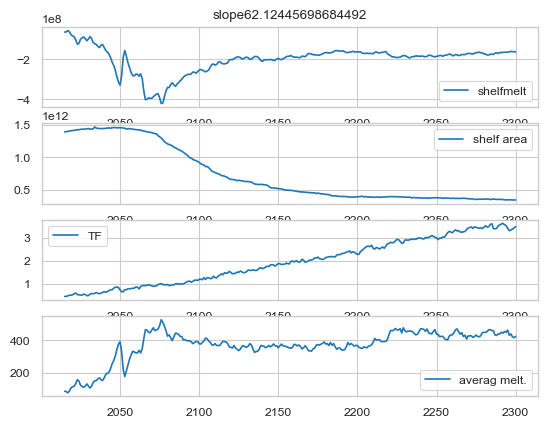

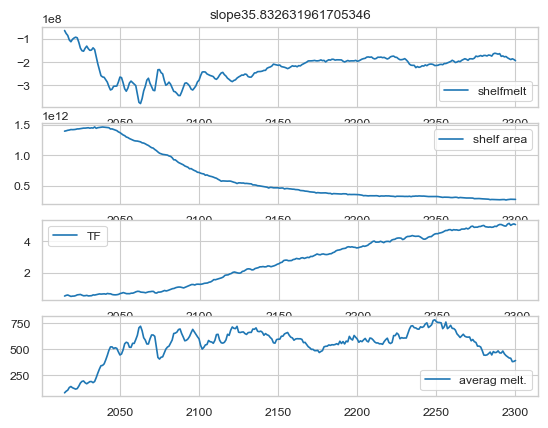

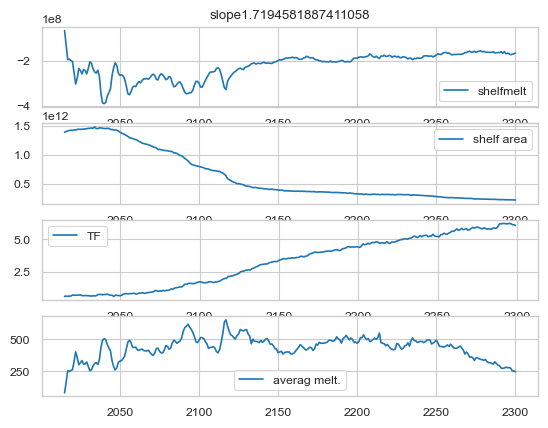

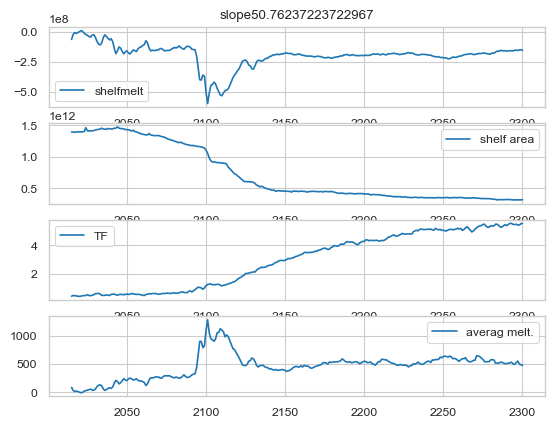

In [97]:
# what is upf with VUB_AISMPALEO:
for i in range (dfpaleo.shape[0]):
    pth_way = dfpaleo.iloc[i].Path
    print(pth_way)
    #get shelf area
    pth_area = f'{pth_helene}/{dfpaleo.iloc[i].Experiment}/iareafl/computed_iareafl_AIS_{dfpaleo.iloc[i].Model}_{dfpaleo.iloc[i].Experiment}.nc'
    pth_tf = f'{pth_imip6hack}/{dfpaleo.iloc[i].Experiment}/thermalforcingBin/computed_thermalforcingBin_AIS_{dfpaleo.iloc[i].Model}_{dfpaleo.iloc[i].Experiment}.nc'
    
    # Melting
    d = xr.open_dataset(pth_way,decode_times=False )
    # Area
    d2 = xr.open_dataset(pth_area,decode_times=False )
    #thermal foring 
    d3 = xr.open_dataset(pth_tf,decode_times=False )
    
    
    tmin = np.min([d.time.size,d2.time.size,d3.time.size])
    #melting per area
    y =-1*d.shelfmelt.values[:tmin]* 365.25 * 24 * 3600/900/d2.iareafl_sector_4.values[:tmin] #GT/m^3 yr
    x = d3.thermalforcingBin.values[:tmin]
    mnan1 = np.isnan(y)
    mnan2 = np.isnan(x)
    mnan = mnan1 | mnan2
    
    slope, intercept, r_value, p_value, std_err = linregress(x[~mnan][:-1], y[~mnan][:-1])
    
#     print(-1*np.nanmean(d.shelfmelt.values[:tmin])* 365.25 * 24 * 3600/900)
#     print(np.nanmean(d2.iareafl.values[:tmin]) )  
    f,ax = plt.subplots(4,1)
    ax[0].set_title('slope' +str(slope))
    ax[0].plot(d.time,d.shelfmelt,label = 'shelfmelt')
    ax[1].plot(d.time,d2.iareafl,label='shelf area')    
    ax[2].plot(d.time,d3.thermalforcingBin,label = 'TF')  
    ax[3].plot(d.time,y,label = 'averag melt.') 
    for i in range(4):
        ax[i].legend()
    f.savefig('paleop_'+str(i)+'.pdf')

In [104]:
1.5*1e10


15000000000.0

In [103]:
15*10**(11)

1500000000000

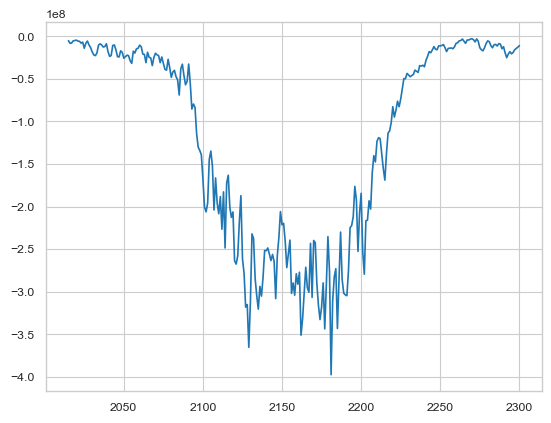

In [36]:
plt.plot(d.time,d.shelfmelt)

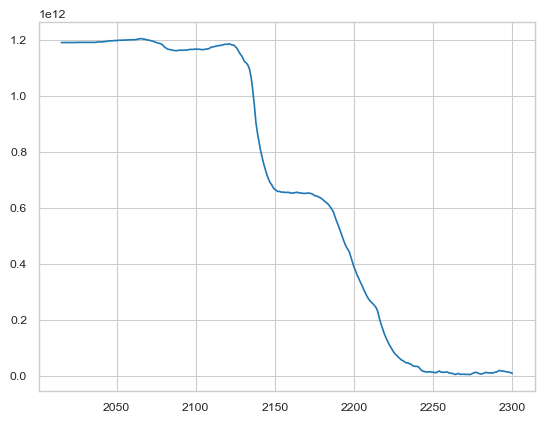

In [38]:
plt.plot(d.time,d2.iareafl)

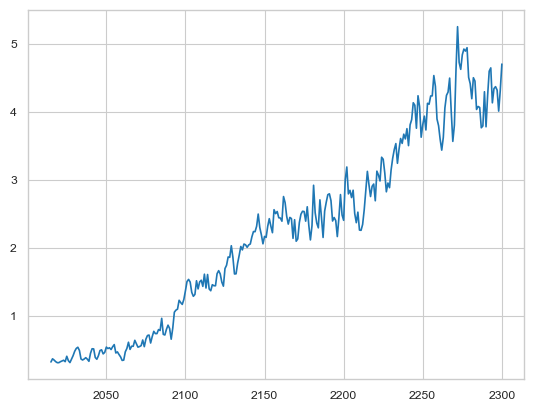

In [40]:
plt.plot(d.time,d3.thermalforcingBin)

nan

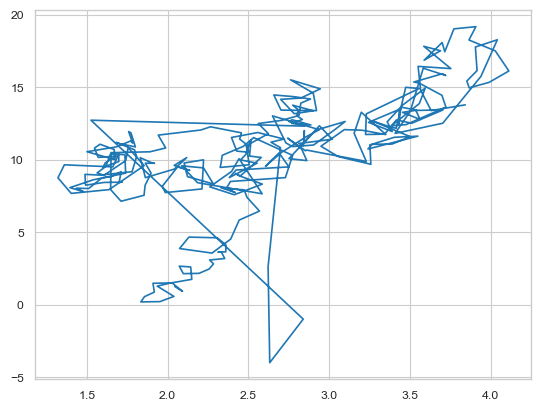

In [12]:
x[0]=np.nan
plt.plot(x[:-1],y[:-1])

slope, intercept, r_value, p_value, std_err = linregress(x, y)
plt.plot(x[:-1],slope*x[:-1]+ intercept)
slope

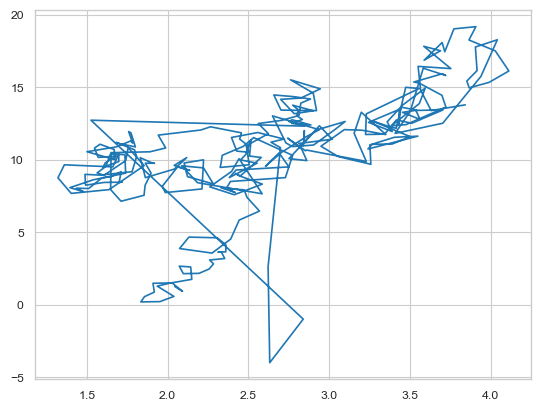

In [11]:
plt.plot(x[:-1],y)

In [28]:
df_sectors= df.copy()
df2 = df.copy()
df_sectors.drop(columns=['Experiment','Model','Path'], inplace=True)

In [59]:
df_sectors

NameError: name 'df_sectors' is not defined